In [4]:
# 가상의 데이터를 만들기 위해
import numpy as np

# 사이킷런의 '나이브 베이즈'에서 '가우시안 베이즈' 임포트
from sklearn.naive_bayes import GaussianNB

#데이터의 시각화를 위해 맷플롯립 임포트
import matplotlib.pyplot as plt

1. 나이브 베이즈

In [5]:
#가상의 데이터를 만듦
#특징, feature, 독립변수 -> X(데이터)
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
#label, 레이블, 종속변수 -> Y(값)
Y = np.array([1, 1, 1, 2, 2, 2])

In [6]:
#머신러닝 알고리즘 정의(이름을 붙인다)
#가우시안 나이브 베이즈 분류기를 정의함
clf = GaussianNB()

#훈련 -> 지도학습(데이터, 라벨)
clf.fit(X, Y)

GaussianNB()

In [7]:
#테스트 -> X값
print( clf.predict([[-0.8, -2]]) )

[1]


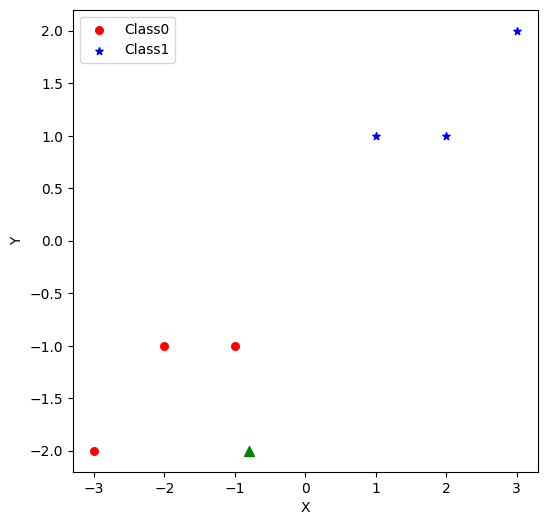

In [8]:
plt.figure(figsize=(6,6))

#마커와 색상으로 클래스를 구분할 수 있도록 합니다.
markers = ['o', '*']
colors = ['red', 'blue']

#0-1, 1-2
for i, cls in enumerate(np.unique(Y)):
  # x의 첫번째 데이터 -> [-1, -1], Y의 첫번째 -> 1
  pts = [(x, y) for (x, y), label in zip(X, Y) if label == cls]
  xs, ys = zip(*pts)
  plt.scatter(
      xs, ys,
      c = colors[i],
      marker = markers[i],
      label = f'Class{i}',
      s = 30
  )
plt.scatter(-0.8, -2, c='green', marker='^', s=50)

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

서포트 벡터 머신

In [9]:
#SV -> 분류(Classifier), 회귀(Regression)
#SVR
from sklearn.svm import LinearSVC

#정의
svm_clf = LinearSVC()

#훈련
svm_clf.fit(X, Y)

#예측
svm_clf.predict([[-0.8, -2]])

array([1])

K - 최근접 이웃 알고리즘

In [10]:
#라이브러리 임포트
from sklearn.neighbors import KNeighborsClassifier

#정의
#몇 개의 이웃을 참고할 것인가?
#하이퍼파라미터 -> ? 1. 경험적 2. Search 알고리즘(최적의 하이퍼파라미터를 찾아주는)
#Grid search, random search
knn_clf = KNeighborsClassifier(n_neighbors=3)

#훈련
knn_clf.fit(X, Y)

#예측
print(knn_clf.predict([[-0.8, -2]]))

[1]


결정트리
sklearn document에서 필요한 데이터를 찾아볼 수 있으면 개발에 도움이 됨

In [11]:
#
from sklearn.tree import DecisionTreeClassifier
#정의
tree_clf = DecisionTreeClassifier()
#훈련
tree_clf.fit(X, Y)
#예측
tree_clf.predict([[-0.8, -2]])

array([1])

데이터 마운트

In [3]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
data_path = '/content/iris.csv'

In [5]:
import pandas as pd

data = pd.read_csv(data_path)

In [22]:
#데이터를 위에서 5줄 출력
data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [23]:
#열의 이름을 출력
data.columns

Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'variety'],
      dtype='object')

In [24]:
#데이터 준비!
#X = data[[x for x in data.columns if x != 'variety']] -> 리스트 컴프리헨션 방식
X = data[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']]
Y = data['variety']

In [25]:
X.head()

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [26]:
Y.head()

,variety
0,Setosa
1,Setosa
2,Setosa
3,Setosa
4,Setosa


In [27]:
#중복없는 값을 출력하여 확인한다
data['variety'].unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

In [28]:
#인코딩
#replace({키:값}) : 키를 값으로 대체한다~
Y = data['variety'].replace({'Setosa':0, 'Versicolor':1, 'Virginica':2}, inplace = True)
Y = data['variety']

<ipython-input-28-032f742b3a4a>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = data['variety'].replace({'Setosa':0, 'Versicolor':1, 'Virginica':2}, inplace = True)


In [29]:
#X의 데이터 길이 == Y의 데이터 길이
len(X) == len(Y)

True

In [30]:
#모델 임포트
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

#정의
#() -> 세팅이 되어 있는 기초 옵션이 적용됨
nb = GaussianNB()
svc = SVC()
knn = KNeighborsClassifier(n_neighbors=3) #주변의 k개의 '이웃'을 보고, 나의 소속을 짐작
dt = DecisionTreeClassifier()

#훈련
nb.fit(X, Y)
svc.fit(X, Y)
knn.fit(X, Y)
dt.dift(X, Y)

#예측
#가상데이터 -> [[5.9,	2.0,	5.1,	1.8]]
print( nb.predict([[5.9,	2.0,	5.1,	1.8]]) )
print( svc.predict([[5.9,	2.0,	5.1,	1.8]]) )
print( knn.predict([[5.9,	2.0,	5.1,	1.8]]) )